# Analyse du Mapping n8n → MCP Tools

Distribution des similarites cosine entre noeuds n8n et tools MCP.
Objectif : evaluer si le mapping est assez bon pour passer de soft targets (KL) a hard targets (InfoNCE).

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../../gru/data")

# Load n8n node embeddings (2114 nodes, 1024D)
print("Loading n8n embeddings...")
with open(DATA_DIR / "n8n-node-embeddings.json") as f:
    n8n_embs_raw = json.load(f)

n8n_ids = list(n8n_embs_raw.keys())
n8n_embs = np.array([n8n_embs_raw[k] for k in n8n_ids], dtype=np.float32)
print(f"n8n nodes: {len(n8n_ids)}, dim: {n8n_embs.shape[1]}")

# Load MCP tool embeddings (expanded vocab: 644 PML + 1288 Smithery)
print("Loading MCP tool embeddings...")
with open(DATA_DIR / "expanded-vocab.json") as f:
    vocab = json.load(f)

pml_count = vocab["pmlToolCount"]
smithery_ids = vocab["smitheryToolIds"]
smithery_embs = np.array(vocab["smitheryToolEmbeddings"], dtype=np.float32)
print(f"Smithery tools: {len(smithery_ids)}, PML tools: {pml_count}")
print(f"Total MCP tools with embeddings: {len(smithery_ids)}")

Loading n8n embeddings...
n8n nodes: 2114, dim: 1024
Loading MCP tool embeddings...
Smithery tools: 1240, PML tools: 644
Total MCP tools with embeddings: 1240


In [2]:
# Compute cosine similarity: each n8n node vs all MCP tools
print("Computing cosine similarities (2114 x 1288 matrix)...")

# Normalize embeddings
n8n_norm = n8n_embs / np.linalg.norm(n8n_embs, axis=1, keepdims=True)
mcp_norm = smithery_embs / np.linalg.norm(smithery_embs, axis=1, keepdims=True)

# Cosine similarity matrix [2114, 1288]
sim_matrix = n8n_norm @ mcp_norm.T
print(f"Similarity matrix shape: {sim_matrix.shape}")

# Top-1 similarity per n8n node
top1_sims = np.max(sim_matrix, axis=1)
top1_indices = np.argmax(sim_matrix, axis=1)

# Top-3 similarities
top3_indices = np.argsort(sim_matrix, axis=1)[:, -3:][:, ::-1]
top3_sims = np.array([sim_matrix[i, top3_indices[i]] for i in range(len(n8n_ids))])

print(f"\nTop-1 similarity stats:")
print(f"  Mean: {top1_sims.mean():.3f}")
print(f"  Median: {np.median(top1_sims):.3f}")
print(f"  Std: {top1_sims.std():.3f}")
print(f"  Min: {top1_sims.min():.3f}")
print(f"  Max: {top1_sims.max():.3f}")
print(f"  >= 0.90: {(top1_sims >= 0.90).sum()} ({(top1_sims >= 0.90).mean()*100:.1f}%)")
print(f"  >= 0.85: {(top1_sims >= 0.85).sum()} ({(top1_sims >= 0.85).mean()*100:.1f}%)")
print(f"  >= 0.80: {(top1_sims >= 0.80).sum()} ({(top1_sims >= 0.80).mean()*100:.1f}%)")
print(f"  >= 0.75: {(top1_sims >= 0.75).sum()} ({(top1_sims >= 0.75).mean()*100:.1f}%)")
print(f"  >= 0.70: {(top1_sims >= 0.70).sum()} ({(top1_sims >= 0.70).mean()*100:.1f}%)")
print(f"  < 0.70:  {(top1_sims < 0.70).sum()} ({(top1_sims < 0.70).mean()*100:.1f}%)")

Computing cosine similarities (2114 x 1288 matrix)...
Similarity matrix shape: (2114, 1240)

Top-1 similarity stats:
  Mean: 0.878
  Median: 0.874
  Std: 0.031
  Min: 0.793
  Max: 0.959
  >= 0.90: 540 (25.5%)
  >= 0.85: 1710 (80.9%)
  >= 0.80: 2111 (99.9%)
  >= 0.75: 2114 (100.0%)
  >= 0.70: 2114 (100.0%)
  < 0.70:  0 (0.0%)


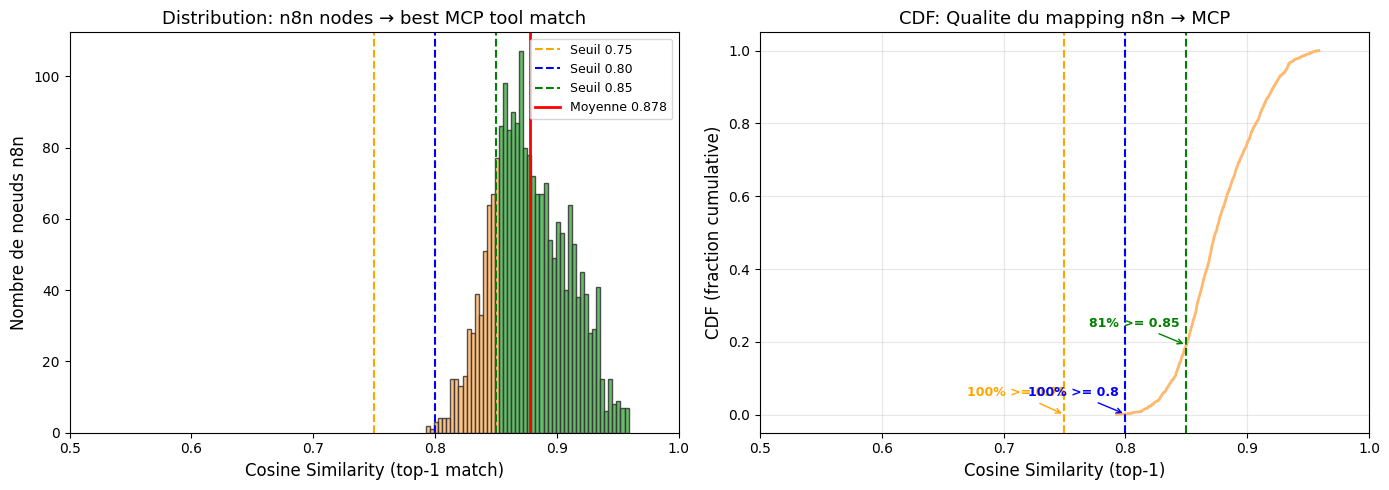

In [3]:
# Distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
counts, bins, patches = ax.hist(top1_sims, bins=50, color='#FFB86F', edgecolor='#333', alpha=0.85)

# Color bins by quality
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 0.85:
        patch.set_facecolor('#4CAF50')  # green - high quality
    elif left_edge >= 0.75:
        patch.set_facecolor('#FFB86F')  # orange - acceptable
    else:
        patch.set_facecolor('#F44336')  # red - risky

ax.axvline(x=0.75, color='orange', linestyle='--', linewidth=1.5, label='Seuil 0.75')
ax.axvline(x=0.80, color='blue', linestyle='--', linewidth=1.5, label='Seuil 0.80')
ax.axvline(x=0.85, color='green', linestyle='--', linewidth=1.5, label='Seuil 0.85')
ax.axvline(x=top1_sims.mean(), color='red', linestyle='-', linewidth=2, label=f'Moyenne {top1_sims.mean():.3f}')
ax.set_xlabel('Cosine Similarity (top-1 match)', fontsize=12)
ax.set_ylabel('Nombre de noeuds n8n', fontsize=12)
ax.set_title('Distribution: n8n nodes → best MCP tool match', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0.5, 1.0)

# CDF
ax2 = axes[1]
sorted_sims = np.sort(top1_sims)
cdf = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)
ax2.plot(sorted_sims, cdf, color='#FFB86F', linewidth=2)
ax2.axvline(x=0.75, color='orange', linestyle='--', linewidth=1.5)
ax2.axvline(x=0.80, color='blue', linestyle='--', linewidth=1.5)
ax2.axvline(x=0.85, color='green', linestyle='--', linewidth=1.5)

# Annotate percentages
for thresh, color in [(0.75, 'orange'), (0.80, 'blue'), (0.85, 'green')]:
    pct = (top1_sims >= thresh).mean() * 100
    ax2.annotate(f'{pct:.0f}% >= {thresh}', xy=(thresh, 1 - pct/100),
                fontsize=9, color=color, fontweight='bold',
                xytext=(thresh - 0.08, 1 - pct/100 + 0.05),
                arrowprops=dict(arrowstyle='->', color=color))

ax2.set_xlabel('Cosine Similarity (top-1)', fontsize=12)
ax2.set_ylabel('CDF (fraction cumulative)', fontsize=12)
ax2.set_title('CDF: Qualite du mapping n8n → MCP', fontsize=13)
ax2.set_xlim(0.5, 1.0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Gap top-1 vs top-2:
  Mean: 0.014
  Median: 0.010
  Gap < 0.02 (tres ambigu): 1611 (76.2%)
  Gap < 0.05 (ambigu):      2061 (97.5%)
  Gap >= 0.10 (clair):       3 (0.1%)


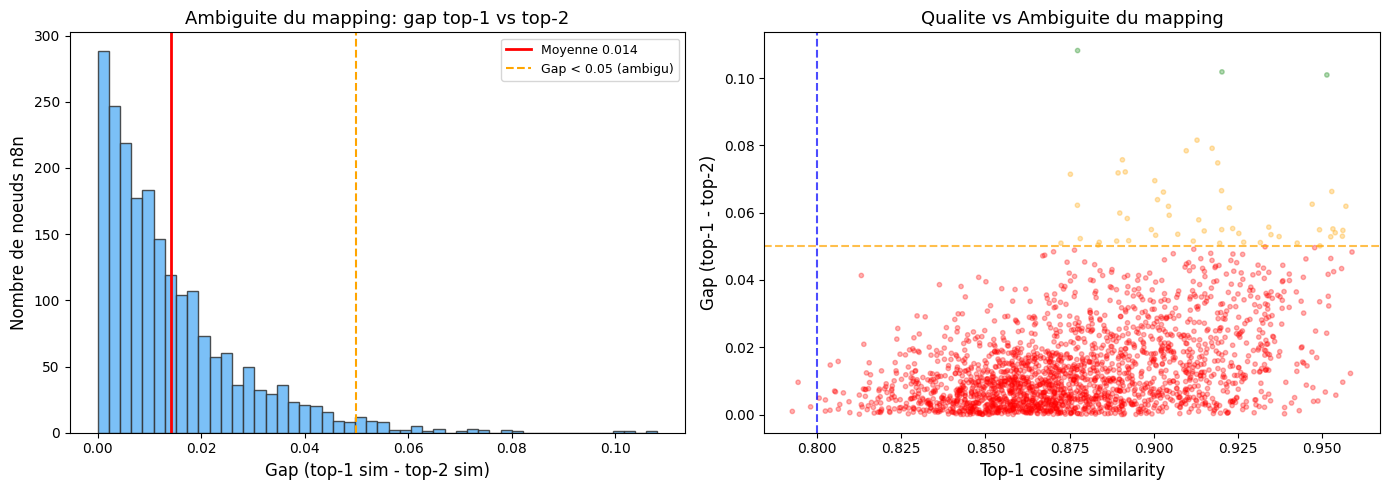

In [4]:
# Top-1 vs Top-2 gap: is the best match clearly dominant?
top2_sims_arr = top3_sims[:, :2]  # [n, 2]
gap = top2_sims_arr[:, 0] - top2_sims_arr[:, 1]  # top1 - top2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gap histogram
ax = axes[0]
ax.hist(gap, bins=50, color='#64B5F6', edgecolor='#333', alpha=0.85)
ax.axvline(x=gap.mean(), color='red', linestyle='-', linewidth=2, label=f'Moyenne {gap.mean():.3f}')
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=1.5, label='Gap < 0.05 (ambigu)')
ax.set_xlabel('Gap (top-1 sim - top-2 sim)', fontsize=12)
ax.set_ylabel('Nombre de noeuds n8n', fontsize=12)
ax.set_title('Ambiguite du mapping: gap top-1 vs top-2', fontsize=13)
ax.legend(fontsize=9)

print(f"Gap top-1 vs top-2:")
print(f"  Mean: {gap.mean():.3f}")
print(f"  Median: {np.median(gap):.3f}")
print(f"  Gap < 0.02 (tres ambigu): {(gap < 0.02).sum()} ({(gap < 0.02).mean()*100:.1f}%)")
print(f"  Gap < 0.05 (ambigu):      {(gap < 0.05).sum()} ({(gap < 0.05).mean()*100:.1f}%)")
print(f"  Gap >= 0.10 (clair):       {(gap >= 0.10).sum()} ({(gap >= 0.10).mean()*100:.1f}%)")

# Scatter: top-1 sim vs gap
ax2 = axes[1]
colors = np.where(gap < 0.05, 'red', np.where(gap < 0.10, 'orange', 'green'))
ax2.scatter(top1_sims, gap, c=colors, alpha=0.3, s=10)
ax2.set_xlabel('Top-1 cosine similarity', fontsize=12)
ax2.set_ylabel('Gap (top-1 - top-2)', fontsize=12)
ax2.set_title('Qualite vs Ambiguite du mapping', fontsize=13)
ax2.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7)
ax2.axvline(x=0.80, color='blue', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [5]:
# Sample mappings: best and worst
sorted_idx = np.argsort(top1_sims)

print("=== TOP 15 BEST MAPPINGS (highest similarity) ===")
for i in sorted_idx[-15:][::-1]:
    n8n_name = n8n_ids[i]
    mcp_name = smithery_ids[top1_indices[i]]
    sim = top1_sims[i]
    g = gap[i]
    print(f"  {sim:.3f} (gap={g:.3f}) {n8n_name} → {mcp_name}")

print(f"\n=== TOP 15 WORST MAPPINGS (lowest similarity, still >= 0.70) ===")
for i in sorted_idx[:15]:
    n8n_name = n8n_ids[i]
    mcp_name = smithery_ids[top1_indices[i]]
    sim = top1_sims[i]
    g = gap[i]
    print(f"  {sim:.3f} (gap={g:.3f}) {n8n_name} → {mcp_name}")

print(f"\n=== 15 MOST AMBIGUOUS (smallest gap, sim >= 0.80) ===")
high_sim_mask = top1_sims >= 0.80
high_sim_gaps = gap.copy()
high_sim_gaps[~high_sim_mask] = 999  # exclude low sim
ambig_idx = np.argsort(high_sim_gaps)[:15]
for i in ambig_idx:
    n8n_name = n8n_ids[i]
    mcp_name = smithery_ids[top1_indices[i]]
    # Also show top-2
    mcp2_name = smithery_ids[top3_indices[i, 1]]
    sim = top1_sims[i]
    g = gap[i]
    print(f"  {sim:.3f} (gap={g:.3f}) {n8n_name} → {mcp_name} vs {mcp2_name}")

=== TOP 15 BEST MAPPINGS (highest similarity) ===
  0.959 (gap=0.048) n8n-nodes-base.googleCalendar:delete → rishipradeep-think41/google-calendar-mcp:delete_event
  0.958 (gap=0.012) n8n-nodes-base.shopifyTool:get → shopify:SHOPIFY_GET_PRODUCT
  0.957 (gap=0.062) n8n-nodes-base.github:delete → github:delete_file
  0.956 (gap=0.055) n8n-nodes-base.googleSheetsTool:deletesheet → googlesheets:GOOGLESHEETS_DELETE_SHEET
  0.956 (gap=0.010) n8n-nodes-base.googleCalendar:get → Motaboy96/google-calendar-mcp-:get_event
  0.956 (gap=0.053) n8n-nodes-base.todoistTool:reopen → todoist:TODOIST_REOPEN_TASK
  0.956 (gap=0.043) n8n-nodes-base.shopifyTool:delete → shopify:SHOPIFY_DELETE_PRODUCT
  0.954 (gap=0.006) n8n-nodes-base.n8n:create → Jimmy974/n8n-workflow-builder:create_workflow
  0.954 (gap=0.054) n8n-nodes-base.pipedriveTool:delete → pipedrive:PIPEDRIVE_DELETE_AN_ACTIVITY_TYPE
  0.953 (gap=0.042) n8n-nodes-base.quickbooks:create → quickbooks:QUICKBOOKS_CREATE_INVOICE
  0.953 (gap=0.055) n8n-n

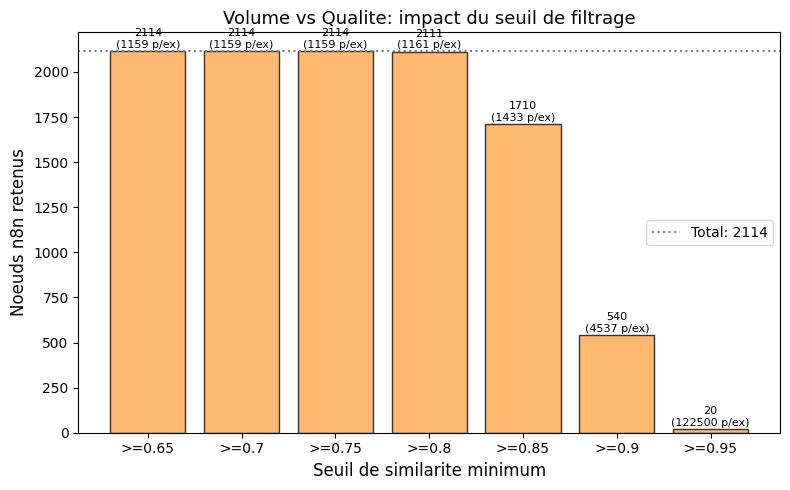


Ratio params/data (avec 3x oversample prod, 1155 prod):
  Seuil 0.65: 2114 n8n + 3465 prod = 5579 ex → 1317 params/ex
  Seuil 0.7: 2114 n8n + 3465 prod = 5579 ex → 1317 params/ex
  Seuil 0.75: 2114 n8n + 3465 prod = 5579 ex → 1317 params/ex
  Seuil 0.8: 2111 n8n + 3465 prod = 5576 ex → 1318 params/ex
  Seuil 0.85: 1710 n8n + 3465 prod = 5175 ex → 1420 params/ex
  Seuil 0.9: 540 n8n + 3465 prod = 4005 ex → 1835 params/ex
  Seuil 0.95: 20 n8n + 3465 prod = 3485 ex → 2109 params/ex


In [6]:
# Summary: how many examples survive each threshold?
# Load the actual training examples count per threshold
thresholds = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
node_counts = [(top1_sims >= t).sum() for t in thresholds]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'>={t}' for t in thresholds], node_counts, color='#FFB86F', edgecolor='#333')

# Annotate with param/data ratio
PARAMS = 7_350_000
for bar, count in zip(bars, node_counts):
    ratio = PARAMS / max(count * 3, 1)  # assume 3x oversample with prod
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}\n({ratio:.0f} p/ex)', ha='center', fontsize=8)

ax.set_xlabel('Seuil de similarite minimum', fontsize=12)
ax.set_ylabel('Noeuds n8n retenus', fontsize=12)
ax.set_title('Volume vs Qualite: impact du seuil de filtrage', fontsize=13)
ax.axhline(y=len(n8n_ids), color='gray', linestyle=':', label=f'Total: {len(n8n_ids)}')
ax.legend()

plt.tight_layout()
plt.show()

print("\nRatio params/data (avec 3x oversample prod, 1155 prod):")
for t, c in zip(thresholds, node_counts):
    total_ex = 1155 * 3 + c  # prod 3x + n8n
    ratio = PARAMS / total_ex
    print(f"  Seuil {t}: {c} n8n + 3465 prod = {total_ex} ex → {ratio:.0f} params/ex")

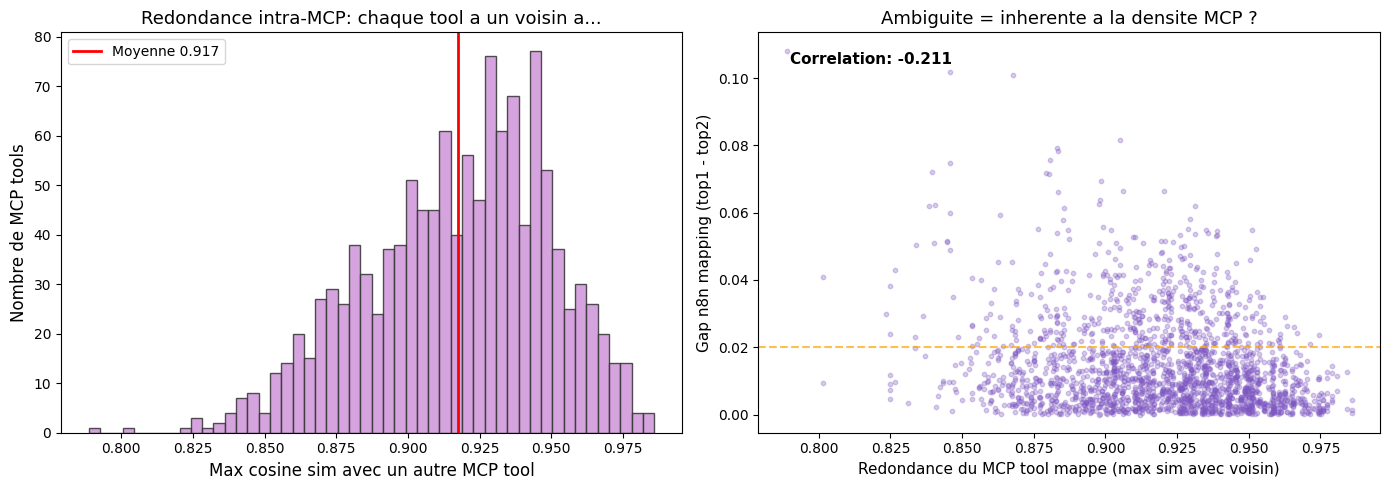


MCP tools: voisin le plus proche en moyenne = 0.917
MCP tools avec voisin >= 0.95: 182 (14.7%)
MCP tools avec voisin >= 0.90: 889 (71.7%)

Correlation gap_n8n vs redondance_mcp: -0.211
→ Si correlation negative forte: l'ambiguite vient de la densite MCP, pas du mapping


In [7]:
# Q1: Le probleme est-il les MCP tools entre eux (trop similaires) ?
# Si les MCP tools eux-memes sont tres similaires, le gap sera faible
# independamment de la qualite du mapping

# Intra-MCP similarity: pour chaque MCP tool, quelle est la sim max avec un autre MCP tool ?
mcp_self_sim = mcp_norm @ mcp_norm.T
np.fill_diagonal(mcp_self_sim, 0)  # ignore self
mcp_max_neighbor = np.max(mcp_self_sim, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(mcp_max_neighbor, bins=50, color='#CE93D8', edgecolor='#333', alpha=0.85)
ax.axvline(x=mcp_max_neighbor.mean(), color='red', linestyle='-', linewidth=2, 
           label=f'Moyenne {mcp_max_neighbor.mean():.3f}')
ax.set_xlabel('Max cosine sim avec un autre MCP tool', fontsize=12)
ax.set_ylabel('Nombre de MCP tools', fontsize=12)
ax.set_title('Redondance intra-MCP: chaque tool a un voisin a...', fontsize=13)
ax.legend()

# Gap between n8n→top1 vs top1→top2 MCP: is this inherent to MCP density?
ax2 = axes[1]
# For each n8n node, the gap it gets is bounded by how close MCP tools are to each other
# near its mapping region
n8n_top1_mcp_neighbor = np.array([mcp_max_neighbor[top1_indices[i]] for i in range(len(n8n_ids))])
ax2.scatter(n8n_top1_mcp_neighbor, gap, alpha=0.3, s=10, c='#7E57C2')
ax2.set_xlabel('Redondance du MCP tool mappe (max sim avec voisin)', fontsize=11)
ax2.set_ylabel('Gap n8n mapping (top1 - top2)', fontsize=11)
ax2.set_title('Ambiguite = inherente a la densite MCP ?', fontsize=13)
ax2.axhline(y=0.02, color='orange', linestyle='--', alpha=0.7)

corr = np.corrcoef(n8n_top1_mcp_neighbor, gap)[0, 1]
ax2.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax2.transAxes, fontsize=11, 
         verticalalignment='top', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nMCP tools: voisin le plus proche en moyenne = {mcp_max_neighbor.mean():.3f}")
print(f"MCP tools avec voisin >= 0.95: {(mcp_max_neighbor >= 0.95).sum()} ({(mcp_max_neighbor >= 0.95).mean()*100:.1f}%)")
print(f"MCP tools avec voisin >= 0.90: {(mcp_max_neighbor >= 0.90).sum()} ({(mcp_max_neighbor >= 0.90).mean()*100:.1f}%)")
print(f"\nCorrelation gap_n8n vs redondance_mcp: {corr:.3f}")
print("→ Si correlation negative forte: l'ambiguite vient de la densite MCP, pas du mapping")

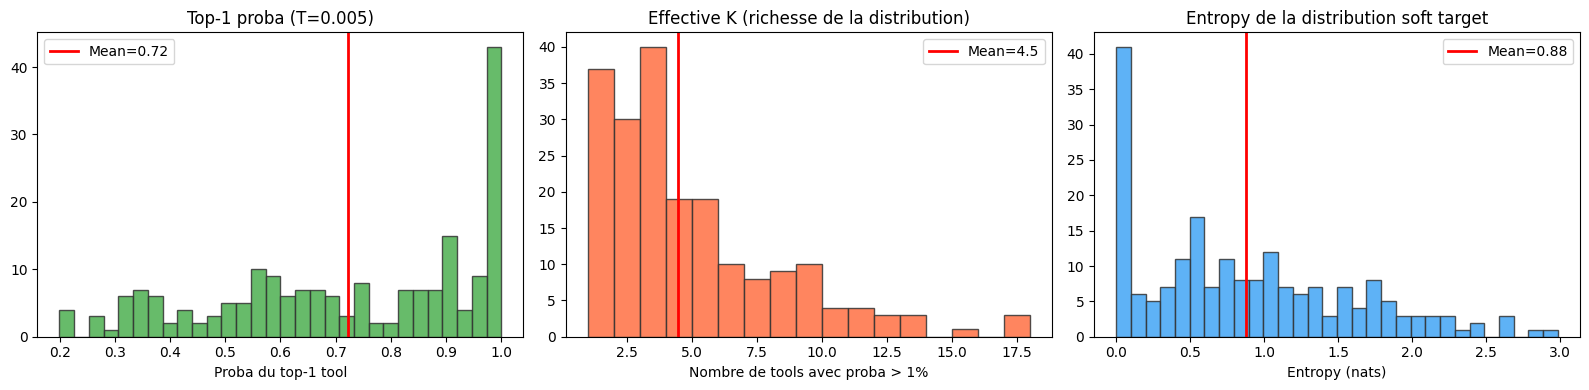

Top-1 proba: mean=0.722, median=0.743
Effective K: mean=4.5, median=3
Entropy: mean=0.88

→ Si top-1 proba ~ 1.0 et K ~ 1: soft targets ≈ hard targets (KL inutile)
→ Si top-1 proba < 0.5 et K > 5: soft targets apportent de l'info (KL utile)


In [8]:
# Q2: Soft target entropy — combien de tools "comptent" dans la distribution KL ?
# Avec T=0.005, la distribution softmax est-elle vraiment peaked ou repartie ?

TEMPERATURE = 0.005

# Pour un echantillon de 200 n8n nodes, calculer la distribution softmax
sample_idx = np.random.RandomState(42).choice(len(n8n_ids), 200, replace=False)

entropies = []
effective_k = []  # nombre de tools avec proba > 1%
top1_probs = []

for i in sample_idx:
    sims = sim_matrix[i]
    # Softmax with temperature
    exp_sims = np.exp((sims - sims.max()) / TEMPERATURE)  # numerical stability
    probs = exp_sims / exp_sims.sum()
    
    # Entropy
    nonzero = probs[probs > 1e-30]
    H = -np.sum(nonzero * np.log(nonzero))
    entropies.append(H)
    
    # Effective K (proba > 1%)
    k = (probs > 0.01).sum()
    effective_k.append(k)
    
    # Top-1 proba
    top1_probs.append(probs.max())

entropies = np.array(entropies)
effective_k = np.array(effective_k)
top1_probs = np.array(top1_probs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(top1_probs, bins=30, color='#4CAF50', edgecolor='#333', alpha=0.85)
axes[0].set_xlabel('Proba du top-1 tool')
axes[0].set_title(f'Top-1 proba (T={TEMPERATURE})')
axes[0].axvline(x=top1_probs.mean(), color='red', linewidth=2, label=f'Mean={top1_probs.mean():.2f}')
axes[0].legend()

axes[1].hist(effective_k, bins=range(1, max(effective_k)+2), color='#FF7043', edgecolor='#333', alpha=0.85)
axes[1].set_xlabel('Nombre de tools avec proba > 1%')
axes[1].set_title('Effective K (richesse de la distribution)')
axes[1].axvline(x=np.mean(effective_k), color='red', linewidth=2, label=f'Mean={np.mean(effective_k):.1f}')
axes[1].legend()

axes[2].hist(entropies, bins=30, color='#42A5F5', edgecolor='#333', alpha=0.85)
axes[2].set_xlabel('Entropy (nats)')
axes[2].set_title('Entropy de la distribution soft target')
axes[2].axvline(x=entropies.mean(), color='red', linewidth=2, label=f'Mean={entropies.mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Top-1 proba: mean={top1_probs.mean():.3f}, median={np.median(top1_probs):.3f}")
print(f"Effective K: mean={np.mean(effective_k):.1f}, median={np.median(effective_k):.0f}")
print(f"Entropy: mean={entropies.mean():.2f}")
print(f"\n→ Si top-1 proba ~ 1.0 et K ~ 1: soft targets ≈ hard targets (KL inutile)")
print(f"→ Si top-1 proba < 0.5 et K > 5: soft targets apportent de l'info (KL utile)")


Running t-SNE on 600 points (1024D → 2D)...
Done.


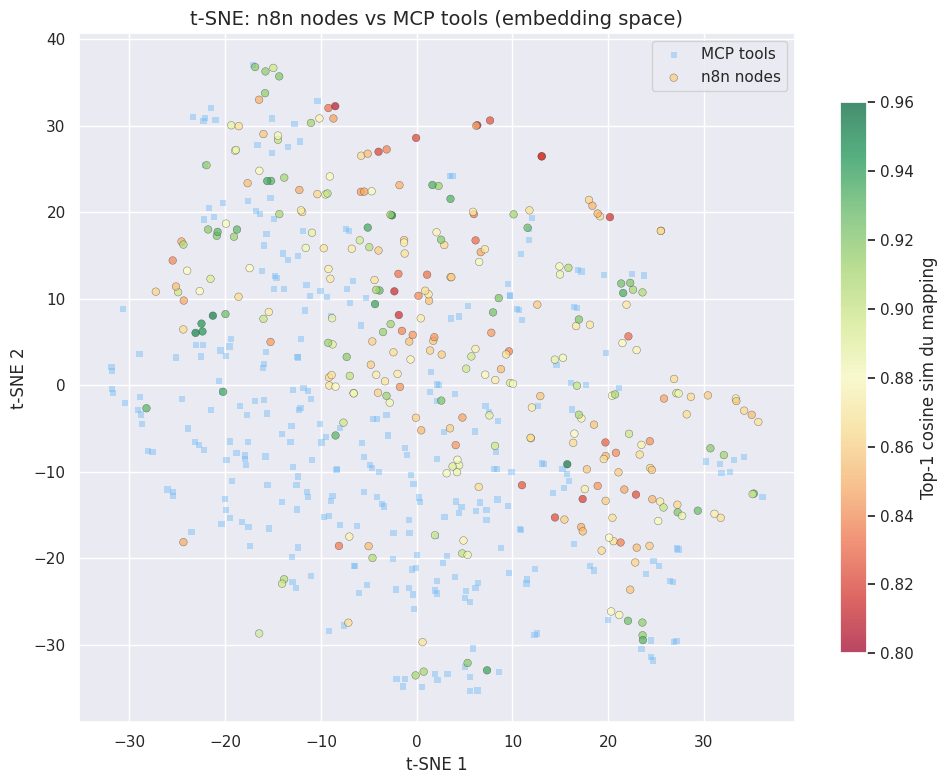

→ Si n8n et MCP sont melanges: les embeddings BGE-M3 voient bien les deux comme similaires
→ Si separes: domain shift reel, le mapping est un 'pont' fragile


In [9]:
# Q3: Visualisation t-SNE — les n8n nodes tombent-ils dans les memes clusters que les MCP tools ?
# Avec seaborn pour le style

import seaborn as sns
from sklearn.manifold import TSNE

sns.set_theme(style="darkgrid", palette="muted")

# Subsample for t-SNE (trop lent sur 3000+)
np.random.seed(42)
n8n_sample = np.random.choice(len(n8n_ids), 300, replace=False)
mcp_sample = np.random.choice(len(smithery_ids), 300, replace=False)

# Combine and project
combined = np.vstack([n8n_norm[n8n_sample], mcp_norm[mcp_sample]])
labels = ['n8n'] * 300 + ['MCP'] * 300

print(f"Running t-SNE on {combined.shape[0]} points (1024D → 2D)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
proj = tsne.fit_transform(combined)
print("Done.")

fig, ax = plt.subplots(figsize=(10, 8))
n8n_proj = proj[:300]
mcp_proj = proj[300:]

# Colorier les n8n par qualite de mapping
n8n_sample_sims = top1_sims[n8n_sample]

scatter_mcp = ax.scatter(mcp_proj[:, 0], mcp_proj[:, 1], c='#64B5F6', alpha=0.4, s=20, 
                          label='MCP tools', marker='s', edgecolors='none')
scatter_n8n = ax.scatter(n8n_proj[:, 0], n8n_proj[:, 1], c=n8n_sample_sims, cmap='RdYlGn',
                          vmin=0.80, vmax=0.96, alpha=0.7, s=30, label='n8n nodes', edgecolors='#333', linewidths=0.3)

plt.colorbar(scatter_n8n, ax=ax, label='Top-1 cosine sim du mapping', shrink=0.8)
ax.set_title('t-SNE: n8n nodes vs MCP tools (embedding space)', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

print("→ Si n8n et MCP sont melanges: les embeddings BGE-M3 voient bien les deux comme similaires")
print("→ Si separes: domain shift reel, le mapping est un 'pont' fragile")

Unique MCP tools touched par les 2114 n8n nodes: 1240/1240 (100.0%)
Unique MCP tools dans le top-5 de tous les n8n: 1240/1240 (100.0%)


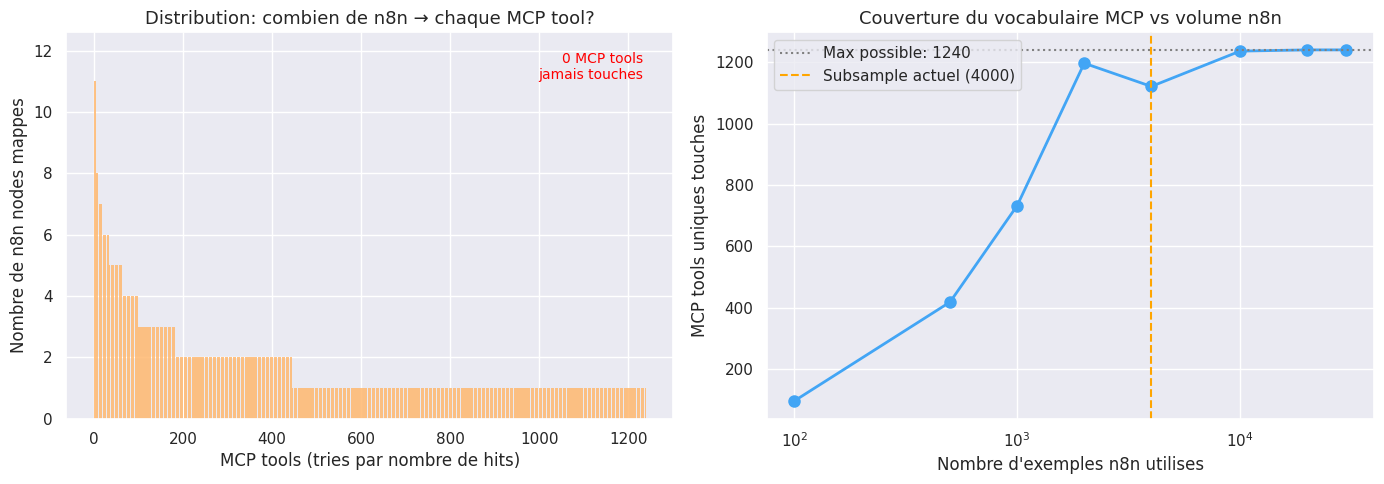


→ Le subsample a 4000 couvre-t-il assez de MCP tools ?
→ Passer a 30K ameliore-t-il significativement la couverture ?


In [10]:
# Q4: Impact du subsample — actuellement on utilise 4000 n8n sur 30K
# Quel est l'impact de passer a 30K complet ?
# Simuler: combien de tools UNIQUES sont touches par K exemples KL ?

# Load the actual training examples to see edge distribution
import struct

# Count how many unique MCP tools are "touched" (top-1 match) across all n8n nodes
unique_mcp_targets = set(top1_indices)
print(f"Unique MCP tools touched par les 2114 n8n nodes: {len(unique_mcp_targets)}/{len(smithery_ids)} ({len(unique_mcp_targets)/len(smithery_ids)*100:.1f}%)")

# Now for the top-5 mapping — how many unique MCP tools are in the soft target support?
top5_indices = np.argsort(sim_matrix, axis=1)[:, -5:]
unique_top5 = set()
for i in range(len(n8n_ids)):
    for j in range(5):
        unique_top5.add(top5_indices[i, j])
print(f"Unique MCP tools dans le top-5 de tous les n8n: {len(unique_top5)}/{len(smithery_ids)} ({len(unique_top5)/len(smithery_ids)*100:.1f}%)")

# Distribution: combien de fois chaque MCP tool est le top-1 d'un n8n node ?
mcp_hit_count = np.zeros(len(smithery_ids), dtype=int)
for idx in top1_indices:
    mcp_hit_count[idx] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hits per MCP tool
ax = axes[0]
sorted_hits = np.sort(mcp_hit_count)[::-1]
nonzero_hits = sorted_hits[sorted_hits > 0]
ax.bar(range(len(nonzero_hits)), nonzero_hits, color='#FFB86F', edgecolor='none', alpha=0.85)
ax.set_xlabel('MCP tools (tries par nombre de hits)', fontsize=12)
ax.set_ylabel('Nombre de n8n nodes mappes', fontsize=12)
ax.set_title(f'Distribution: combien de n8n → chaque MCP tool?', fontsize=13)
ax.text(0.95, 0.95, f'{(mcp_hit_count == 0).sum()} MCP tools\njamais touches', 
        transform=ax.transAxes, ha='right', va='top', fontsize=10, color='red')

# CDF of coverage vs number of n8n nodes
ax2 = axes[1]
# For random subsets of size K, estimate unique MCP tools touched
ks = [100, 500, 1000, 2000, 4000, 10000, 20000, 30000]
coverage = []
for k in ks:
    if k <= len(n8n_ids):
        # Monte Carlo: 20 random samples
        unique_counts = []
        for _ in range(20):
            sample = np.random.choice(len(n8n_ids), min(k, len(n8n_ids)), replace=k > len(n8n_ids))
            uniq = len(set(top1_indices[sample]))
            unique_counts.append(uniq)
        coverage.append(np.mean(unique_counts))
    else:
        # With replacement for > 2114 (simulating n8n workflow edges, not unique nodes)
        sample = np.random.choice(len(n8n_ids), k, replace=True)
        coverage.append(len(set(top1_indices[sample])))

ax2.plot(ks, coverage, 'o-', color='#42A5F5', linewidth=2, markersize=8)
ax2.axhline(y=len(unique_mcp_targets), color='gray', linestyle=':', label=f'Max possible: {len(unique_mcp_targets)}')
ax2.axvline(x=4000, color='orange', linestyle='--', label='Subsample actuel (4000)')
ax2.set_xlabel('Nombre d\'exemples n8n utilises', fontsize=12)
ax2.set_ylabel('MCP tools uniques touches', fontsize=12)
ax2.set_title('Couverture du vocabulaire MCP vs volume n8n', fontsize=13)
ax2.legend()
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

print(f"\n→ Le subsample a 4000 couvre-t-il assez de MCP tools ?")
print(f"→ Passer a 30K ameliore-t-il significativement la couverture ?")

Loaded 1993 mappings (T1=676, T2=1168, T3=149)
Average top-1 sim: 0.862


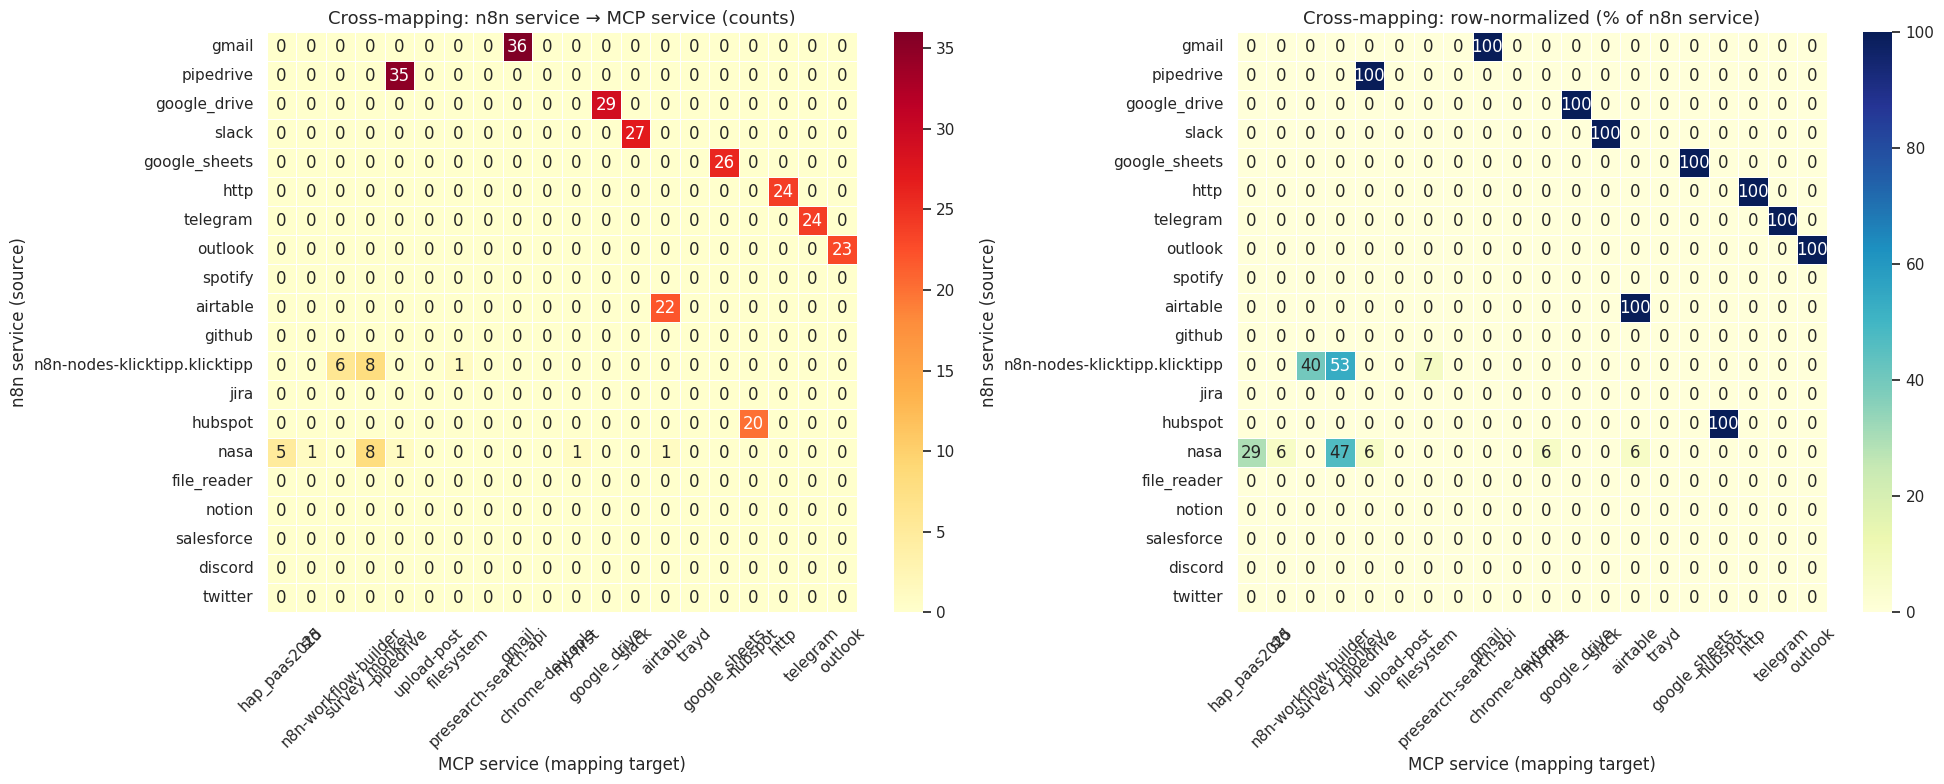


--- Tier stats ---
  Tier 1: 676 (33.9%)
  Tier 2: 1168 (58.6%)
  Tier 3: 149 (7.5%)

--- Diagonal accuracy (n8n service == MCP service) ---
  Top services: 411/451 (91.1%)

--- Per-service accuracy (top 20) ---
  ✓ gmail: 36/36 (100%)
  ✓ pipedrive: 35/35 (100%)
  ✓ google_drive: 29/29 (100%)
  ✓ slack: 27/27 (100%)
  ✓ google_sheets: 26/26 (100%)
  ✓ http: 24/24 (100%)
  ✓ telegram: 24/24 (100%)
  ✓ outlook: 23/23 (100%)
  ✓ spotify: 23/23 (100%)
  ✓ airtable: 22/22 (100%)
  ✓ github: 22/22 (100%)
  ✗ n8n-nodes-klicktipp.klicktipp: 0/22 (0%)
  ✓ jira: 21/21 (100%)
  ✓ hubspot: 20/20 (100%)
  ✗ nasa: 0/18 (0%)
  ✓ file_reader: 16/16 (100%)
  ✓ notion: 16/16 (100%)
  ✓ salesforce: 16/16 (100%)
  ✓ discord: 16/16 (100%)
  ✓ twitter: 15/15 (100%)


In [11]:
# Q5: Cross-mapping heatmap using ACTUAL tier system results
# (uses n8n-mcp-mapping-summary.json from build-soft-targets.ts)

import re
from collections import Counter

# Load the mapping summary produced by build-soft-targets.ts
summary_path = DATA_DIR / "n8n-mcp-mapping-summary.json"
if not summary_path.exists():
    print("ERROR: n8n-mcp-mapping-summary.json not found!")
    print("Run: cd lib/gru && DATABASE_URL=... npx tsx src/n8n/build-soft-targets.ts")
else:
    with open(summary_path) as f:
        summary = json.load(f)
    
    mappings = summary["mappings"]
    stats = summary["stats"]
    print(f"Loaded {stats['total']} mappings (T1={stats['tier1']}, T2={stats['tier2']}, T3={stats['tier3']})")
    print(f"Average top-1 sim: {stats['avgTopSim']:.3f}")
    
    # --- Extract service categories from ACTUAL mapping data ---
    def extract_n8n_service(n8n_key):
        """Extract service from n8n key using same logic as TS"""
        base = re.sub(r'^n8n-nodes-base\.', '', n8n_key)
        base = re.sub(r'^@n8n/n8n-nodes-langchain\.', '', base)
        base = re.sub(r'^@[^/]+/[^.]+\.', '', base)
        base = base.split(':')[0]
        # camelCase split + remove suffixes
        segments = re.sub(r'([a-z])([A-Z])', r'\1_\2', base).lower().split('_')
        ignored = {'trigger', 'tool', 'v2', 'v3', 'v4', 'new'}
        filtered = [s for s in segments if s not in ignored]
        return '_'.join(filtered) if filtered else base.lower()
    
    def extract_mcp_service(mcp_id):
        """Extract service from MCP tool ID"""
        server = mcp_id.split(':')[0].lower()
        if '/' in server:
            repo = server.split('/')[-1]
            repo = re.sub(r'^mcp[-_]?', '', repo)
            repo = re.sub(r'[-_]?mcp$', '', repo)
            repo = re.sub(r'[-_]?server$', '', repo)
            repo = re.sub(r'[-_]?bot$', '', repo)
            return repo if len(repo) >= 3 else server
        return server if server not in ('std', 'exa') else 'std'
    
    # Build the data: use the tier system's service field when available (Tier 1),
    # otherwise fall back to extracted service names
    n8n_services = []
    mcp_services = []
    tiers = []
    
    for n8n_key, info in mappings.items():
        n8n_svc = info.get("service") or extract_n8n_service(n8n_key)
        mcp_svc = info.get("service") or extract_mcp_service(info["mcp"])
        n8n_services.append(n8n_svc)
        mcp_services.append(mcp_svc)
        tiers.append(info["tier"])
    
    # Count per-service (n8n side)
    n8n_svc_counts = Counter(n8n_services)
    mcp_svc_counts = Counter(mcp_services)
    
    # Top services for the heatmap (at least 5 nodes)
    MIN_COUNT = 5
    top_n8n_svcs = [s for s, c in n8n_svc_counts.most_common(20) if c >= MIN_COUNT]
    top_mcp_svcs = [s for s, c in mcp_svc_counts.most_common(20) if c >= MIN_COUNT]
    
    # Build cross-mapping matrix
    cross = Counter()
    for ns, ms in zip(n8n_services, mcp_services):
        cross[(ns, ms)] += 1
    
    matrix = np.zeros((len(top_n8n_svcs), len(top_mcp_svcs)))
    for i, ns in enumerate(top_n8n_svcs):
        for j, ms in enumerate(top_mcp_svcs):
            matrix[i, j] = cross.get((ns, ms), 0)
    
    # Normalize rows (percentage of each n8n service)
    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    matrix_pct = matrix / row_sums * 100
    
    # --- Plot 1: Raw counts heatmap ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    ax = axes[0]
    sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlOrRd',
                xticklabels=top_mcp_svcs, yticklabels=top_n8n_svcs, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('MCP service (mapping target)', fontsize=12)
    ax.set_ylabel('n8n service (source)', fontsize=12)
    ax.set_title('Cross-mapping: n8n service → MCP service (counts)', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    
    # --- Plot 2: Row-normalized (%) ---
    ax2 = axes[1]
    sns.heatmap(matrix_pct, annot=True, fmt='.0f', cmap='YlGnBu',
                xticklabels=top_mcp_svcs, yticklabels=top_n8n_svcs, ax=ax2,
                linewidths=0.5, linecolor='white', vmin=0, vmax=100)
    ax2.set_xlabel('MCP service (mapping target)', fontsize=12)
    ax2.set_ylabel('n8n service (source)', fontsize=12)
    ax2.set_title('Cross-mapping: row-normalized (% of n8n service)', fontsize=13)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # --- Diagonal accuracy ---
    diagonal_hits = 0
    diagonal_total = 0
    for ns, ms in zip(n8n_services, mcp_services):
        if ns in top_n8n_svcs:
            diagonal_total += 1
            if ns == ms:
                diagonal_hits += 1
    
    print(f"\n--- Tier stats ---")
    tier_counts = Counter(tiers)
    for t in sorted(tier_counts):
        print(f"  Tier {t}: {tier_counts[t]} ({tier_counts[t]/len(tiers)*100:.1f}%)")
    
    print(f"\n--- Diagonal accuracy (n8n service == MCP service) ---")
    print(f"  Top services: {diagonal_hits}/{diagonal_total} ({diagonal_hits/max(diagonal_total,1)*100:.1f}%)")
    
    # Show services where diagonal is strong vs weak
    print(f"\n--- Per-service accuracy (top 20) ---")
    for svc in top_n8n_svcs[:20]:
        total = sum(1 for ns, ms in zip(n8n_services, mcp_services) if ns == svc)
        correct = sum(1 for ns, ms in zip(n8n_services, mcp_services) if ns == svc and ns == ms)
        pct = correct / max(total, 1) * 100
        marker = "✓" if pct >= 50 else "✗" if pct == 0 else "~"
        print(f"  {marker} {svc}: {correct}/{total} ({pct:.0f}%)")